# Analisi Prodotti - Azienda NG

## 1. Web Scraping Multi-pagina e Raccolta Link
In questa prima fase iteriamo su tutte le pagine del catalogo online dell'Azienda NG (da 1 a 10). Per ogni pagina, estraiamo i dati di base visibili nella *product card*:
* **Nome del prodotto**
* **Prezzo** di listino
* **Link di dettaglio** della pagina prodotto (che codifichiamo in Base64 per gestione sicura delle stringhe URL).

Questa raccolta ci fornirà la base per le successive operazioni di "deep scraping".

In [1]:
from Library import *
load_dotenv()
URL_NG = os.getenv("URL_NG")
link_product_NG = os.getenv("link_product_NG")

Lista_scarpe_NG = [] 
Prezzo_scarpe_NG = []
Product_links_NG = []

for page in range(1,11):
    url_pages = f"{URL_NG}?page={page}"
    print(f"Scraping pagina: {page}")

    response_NG = requests.get(url_pages)
    html_NG = response_NG.text
    soup_NG = bs(html_NG)
    
    titles_NG = soup_NG.find_all("h2", attrs={"class": "product-title"})
    
    for title in titles_NG:
        #print(title.get_text(strip=True))
        Lista_scarpe_NG.append(title.get_text(strip=True))
        link_tag = title.find("a")
        link_product = link_product_NG + link_tag.get("href")
        link_nascosti = base64.b64encode(link_product.encode('utf-8')).decode('utf-8')
        Product_links_NG.append(link_nascosti)
        
        
    prices_NG = soup_NG.find_all("span", attrs={"class": "price"})
    
    for price in prices_NG:
        #print(price.get_text(strip=True))
        Prezzo_scarpe_NG.append(price.get_text(strip=True))
        
print("Fine scraping")
Dict_NG = {"Scarpe":Lista_scarpe_NG,"Prezzo":Prezzo_scarpe_NG,"Link": Product_links_NG}

Scraping pagina: 1
Scraping pagina: 2
Scraping pagina: 3
Scraping pagina: 4
Scraping pagina: 5
Scraping pagina: 6
Scraping pagina: 7
Scraping pagina: 8
Scraping pagina: 9
Scraping pagina: 10
Fine scraping


## 2. Data Cleaning: Formattazione dei Prezzi
Trasferiamo i dati estratti nel DataFrame e normalizziamo la colonna dei prezzi. 
Per gestire la specifica formattazione:
* Rimuoviamo il simbolo dell'Euro.
* Eliminiamo il separatore delle migliaia (il punto).
* Sostituiamo il separatore dei decimali (la virgola) con il punto, compatibile con Python.
* Effettuiamo il cast della colonna nel formato numerico `float`.

In [2]:
df_NG = pd.DataFrame(Dict_NG)

print(df_NG.info())
#Rimuoviamo il simbolo dell'Euro e gli eventuali spazi vuoti
df_NG["Prezzo"] = df_NG["Prezzo"].str.replace("€", "", regex=False).str.strip()

#da 1.200,00 a 1200,00)
df_NG["Prezzo"] = df_NG["Prezzo"].str.replace(".", "", regex=False)

#da 129,00 a 129.00)
df_NG["Prezzo"] = df_NG["Prezzo"].str.replace(",", ".", regex=False)

#convertiamo in float
df_NG["Prezzo"] = df_NG["Prezzo"].astype(float)

df_NG.info()
print("\nPrime righe del DataFrame pulito:")
print(df_NG.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Scarpe  160 non-null    object
 1   Prezzo  160 non-null    object
 2   Link    160 non-null    object
dtypes: object(3)
memory usage: 3.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Scarpe  160 non-null    object 
 1   Prezzo  160 non-null    float64
 2   Link    160 non-null    object 
dtypes: float64(1), object(2)
memory usage: 3.9+ KB

Prime righe del DataFrame pulito:
                      Scarpe  Prezzo  \
0      Men’s Leather Loafers   139.5   
1      Men’s Leather Loafers   139.5   
2      Men’s Leather Loafers   139.5   
3  Men’s Patent Oxford Shoes   149.5   
4       Men's Leather Derbys   149.5   

                                                Link  

## 3. Deep Scraping: Dettagli Prodotto
Per arricchire il nostro dataset, effettuiamo una seconda ondata di scraping visitando dinamicamente il link di ogni singolo prodotto. 
Attraverso questa operazione puntuale (ritardata da un `time.sleep(1)` per non sovraccaricare il server), estraiamo attributi specifici contenuti nelle tabelle informative del sito: **Categoria, Sottocategoria, Paese d'Origine e Uso del prodotto**.

In [3]:
P_Category_NG = []
P_Subcategory = []
P_CountryOrigin = []
P_Uses = []


for link_p in df_NG["Link"]:
    link_reale = base64.b64decode(link_p.encode('utf-8')).decode('utf-8')
    response_NG_p = requests.get(link_reale)
    html_NG_p = response_NG_p.text
    soup_NG_p = bs(html_NG_p)
     
    p_cat_NG = soup_NG_p.find_all("th", attrs={"class": "whitespace-nowrap"})
    
    for category in p_cat_NG:
        #corrispondenza esatta
        testo_NG = category.get_text(strip=True).lower().replace(":", "").strip()
        valore_td_NG = category.find_next_sibling("td")
        
        if valore_td_NG:
            testo_valore_NG = valore_td_NG.get_text(strip=True)

            if testo_NG == "product category":
                subcat_val_NG = testo_valore_NG
            elif testo_NG == "product":
                cat_val_NG = testo_valore_NG
            elif testo_NG == "country of origin":
                country_val_NG = testo_valore_NG
            elif testo_NG == "product uses":
                uses_val_NG = testo_valore_NG
                
    P_Category_NG.append(cat_val_NG)
    P_Subcategory.append(subcat_val_NG)
    P_CountryOrigin.append(country_val_NG)
    P_Uses.append(uses_val_NG)

    #deelay per non mandare in tilt
    time.sleep(1)

df_NG["Categoria"] = P_Category_NG
df_NG["Sottocategoria"] = P_Subcategory
df_NG["Origine"] = P_CountryOrigin
df_NG["Uso"] = P_Uses

print("Scraping completato!")
print(df_NG.head())
df_NG.info()

Scraping completato!
                      Scarpe  Prezzo  \
0      Men’s Leather Loafers   139.5   
1      Men’s Leather Loafers   139.5   
2      Men’s Leather Loafers   139.5   
3  Men’s Patent Oxford Shoes   149.5   
4       Men's Leather Derbys   149.5   

                                                Link Categoria  \
0  aHR0cHM6Ly9uZXJvZ2lhcmRpbmkuaXQvcHJvZHVjdHMvbW...  Footwear   
1  aHR0cHM6Ly9uZXJvZ2lhcmRpbmkuaXQvcHJvZHVjdHMvbW...  Footwear   
2  aHR0cHM6Ly9uZXJvZ2lhcmRpbmkuaXQvcHJvZHVjdHMvbW...  Footwear   
3  aHR0cHM6Ly9uZXJvZ2lhcmRpbmkuaXQvcHJvZHVjdHMvc3...  Footwear   
4  aHR0cHM6Ly9uZXJvZ2lhcmRpbmkuaXQvcHJvZHVjdHMvc3...  Footwear   

                        Sottocategoria Origine             Uso  
0  Clothes, textiles, fashion products   Italy  Daily footwear  
1  Clothes, textiles, fashion products   Italy  Daily footwear  
2  Clothes, textiles, fashion products   Italy  Daily footwear  
3  Clothes, textiles, fashion products   Italy  Daily footwear  
4  Clothes, text

### 3.1 Ottimizzazione del Dataset
Verificando i dati estratti dal *deep scraping*, notiamo che le variabili "Categoria", "Sottocategoria", "Origine" e "Uso" presentano un singolo valore univoco per tutto il catalogo analizzato (es. tutti i prodotti sono "Made in Italy"). Per non appesantire il DataFrame con dati a varianza zero, procediamo a rimuovere queste colonne.

In [4]:
df_NG_salvato = df_NG
df_NG_salvato.shape
df_NG_salvato.info()
df_NG_salvato[["Categoria", "Sottocategoria", "Origine", "Uso"]].nunique()

#solo valore per colonna le droppiamo:
df_NG_salvato = df_NG_salvato.drop(columns=["Categoria", "Sottocategoria", "Origine", "Uso"])
df_NG_salvato.head()
df_NG_salvato["Prezzo"].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Scarpe          160 non-null    object 
 1   Prezzo          160 non-null    float64
 2   Link            160 non-null    object 
 3   Categoria       160 non-null    object 
 4   Sottocategoria  160 non-null    object 
 5   Origine         160 non-null    object 
 6   Uso             160 non-null    object 
dtypes: float64(1), object(6)
memory usage: 8.9+ KB


count    160.000000
mean     149.045000
std       25.329198
min       75.000000
25%      145.000000
50%      149.500000
75%      159.500000
max      349.000000
Name: Prezzo, dtype: float64

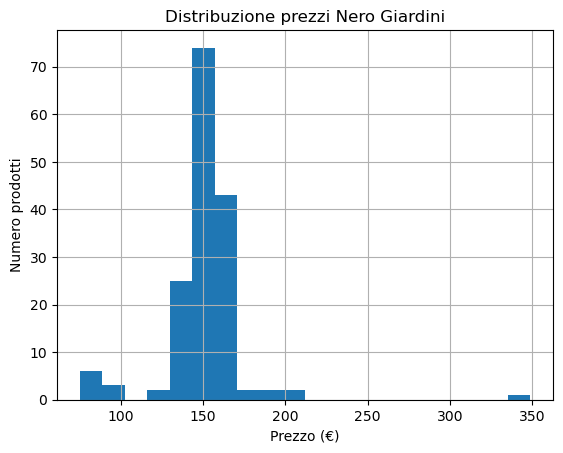

In [5]:
df_NG_salvato["Prezzo"].hist(bins=20)
plt.title("Distribuzione prezzi Nero Giardini")
plt.xlabel("Prezzo (€)")
plt.ylabel("Numero prodotti")
plt.show()

In [6]:
df_NG_salvato["Scarpe"].value_counts()
df_NG_salvato["Scarpe"] = df_NG_salvato["Scarpe"].str.title()
df_NG_salvato["Scarpe"].value_counts()

df_NG_salvato["Scarpe"] = df_NG_salvato["Scarpe"].str.replace("Men'S", "Men's")
df_NG_salvato["Scarpe"].value_counts()

df_NG_salvato["Scarpe"] = df_NG_salvato["Scarpe"].str.replace(r"Men['\u2019]S", "Men's", regex=True)
df_NG_salvato["Scarpe"].value_counts()

df_NG_salvato["Scarpe"].unique()

array(["Men's Leather Loafers", "Men's Patent Oxford Shoes",
       "Men's Leather Derbys", "Men's Double Leather Buckle",
       "Men's Leather Sneakers", "Men's Suede Loafers",
       "Men's Suede Derby Shoes", "Men's Leather And Suede Sneakers",
       "Men's Suede Sneakers", "Men's Leather Tie-Up Shoes",
       "Men's Suede And Canvas Sneakers",
       "Men's Leather And Canvas Sneakers", "Men's Suede Slippers",
       "Men's Leather Slippers", "Men's Suede Tie-Up Shoes",
       "Men's Patent Leather Loafers", "Men's Patent Derby Shoes",
       "Men's Leather, Canvas And Suede Sneakers",
       "Men's Patent Tie-Up Shoes", "Men's Leather Combat Boots",
       "Men's High Top Leather Sneakers", "Men's Leather Chelsea Boots",
       "Men's Suede Chelsea Boots", "Men's Suede Desert Boots",
       "Men's Suede, Leather And Canvas Sneakers"], dtype=object)

## 4. Standardizzazione e Feature

### 4.1 Standardizzazione della Nomenclatura
I nomi dei prodotti presentano lievi discrepanze tipografiche (es. apici e virgolette diverse per la stringa "Men's"). Applichiamo delle regole di *Regular Expression (RegEx)* per uniformare completamente il naming delle scarpe e facilitare le future ricerche testuali.

In [7]:
scarpe = df_NG_salvato["Scarpe"].str.lower()

#Materiale
df_NG_salvato["Materiale"] = "Da definire"
df_NG_salvato.loc[scarpe.str.contains("canvas"),"Materiale"] = "Canvas"
df_NG_salvato.loc[scarpe.str.contains("suede"),"Materiale"] = "Suede"
df_NG_salvato.loc[scarpe.str.contains("patent"),"Materiale"] = "Patent"
df_NG_salvato.loc[scarpe.str.contains("leather"),"Materiale"] = "Leather"

#tipo
df_NG_salvato["Tipo"] = "Da definire"
df_NG_salvato.loc[scarpe.str.contains("sneaker"),"Tipo"] = "Sneakers"
df_NG_salvato.loc[scarpe.str.contains("loafer"),"Tipo"] = "Loafers"
df_NG_salvato.loc[scarpe.str.contains("slipper"),"Tipo"] = "Slippers"
df_NG_salvato.loc[scarpe.str.contains("oxford"),"Tipo"] = "Oxford Shoes"
df_NG_salvato.loc[scarpe.str.contains("derby"),"Tipo"] = "Derby Shoes"
df_NG_salvato.loc[scarpe.str.contains("tie-up"),"Tipo"] = "Tie-Up Shoes"
df_NG_salvato.loc[scarpe.str.contains("boots"),"Tipo"] = "Boots"
df_NG_salvato.loc[scarpe.str.contains("chelsea boots"), "Tipo"] = "Chelsea Boots"
df_NG_salvato.loc[scarpe.str.contains("ankle boots"),"Tipo"] = "Ankle Boots"
df_NG_salvato.loc[scarpe.str.contains("combat boots"),"Tipo"] = "Combat Boots"
df_NG_salvato.loc[scarpe.str.contains("desert boots"),"Tipo"] = "Desert Boots"

#Sottotipo
df_NG_salvato["Sottotipo"] = df_NG_salvato["Tipo"]
df_NG_salvato.loc[scarpe.str.contains("sneaker") & ~scarpe.str.contains("high"), "Sottotipo"] = "Low Sneakers"
df_NG_salvato.loc[scarpe.str.contains("sneaker") &  scarpe.str.contains("high"), "Sottotipo"] = "High Top Sneakers"
df_NG_salvato["Sottotipo"].value_counts()


Sottotipo
Low Sneakers         71
Loafers              30
Tie-Up Shoes         22
Chelsea Boots        11
Derby Shoes           9
Slippers              9
Combat Boots          2
High Top Sneakers     2
Desert Boots          2
Oxford Shoes          1
Da definire           1
Name: count, dtype: int64

In [8]:
df_NG_salvato.loc[scarpe.str.contains("buckle"), "Tipo"] = "Buckle Shoes"
df_NG_salvato.loc[scarpe.str.contains("buckle"), "Sottotipo"] = "Buckle Shoes"

df_NG_salvato["Sottotipo"].value_counts()

Sottotipo
Low Sneakers         71
Loafers              30
Tie-Up Shoes         22
Chelsea Boots        11
Derby Shoes           9
Slippers              9
Combat Boots          2
High Top Sneakers     2
Desert Boots          2
Oxford Shoes          1
Buckle Shoes          1
Name: count, dtype: int64

In [9]:
df_NG_salvato["Tipo"].value_counts()

Tipo
Sneakers         73
Loafers          30
Tie-Up Shoes     22
Chelsea Boots    11
Derby Shoes       9
Slippers          9
Combat Boots      2
Desert Boots      2
Oxford Shoes      1
Buckle Shoes      1
Name: count, dtype: int64

### 4.2 Creazione Variabili "Materiale" e "Tipo"
A differenza di altri competitor, l'Azienda NG inserisce le informazioni su materiale e modello direttamente nel nome del prodotto. 
Tramite tecniche di *string matching* (`str.contains`), intercettiamo specifiche parole chiave (es. "leather", "suede", "patent", "sneaker", "loafer") per popolare automaticamente due nuove colonne analitiche: **Materiale** e **Tipo**. Questo ci permette anche di isolare la **Sottotipologia** (es. "Low Sneakers" vs "High Top Sneakers").

In [10]:
df_NG_salvato["Sottotipo"] = df_NG_salvato["Materiale"] + " " + df_NG_salvato["Tipo"]

# Sneakers le gestiamo a parte perché hanno High Top vs Low
df_NG_salvato.loc[scarpe.str.contains("sneaker") & ~scarpe.str.contains("high"),"Sottotipo"] = "Low Sneakers"
df_NG_salvato.loc[scarpe.str.contains("sneaker") &  scarpe.str.contains("high"),"Sottotipo"] = "High Top Sneakers"

df_NG_salvato["Sottotipo"].value_counts()
print(df_NG_salvato.columns)
df_NG_salvato = df_NG_salvato.drop(columns=["Link"])
df_NG_salvato.to_csv("Azienda NG.csv",index = False)

Index(['Scarpe', 'Prezzo', 'Link', 'Materiale', 'Tipo', 'Sottotipo'], dtype='object')


<Axes: >

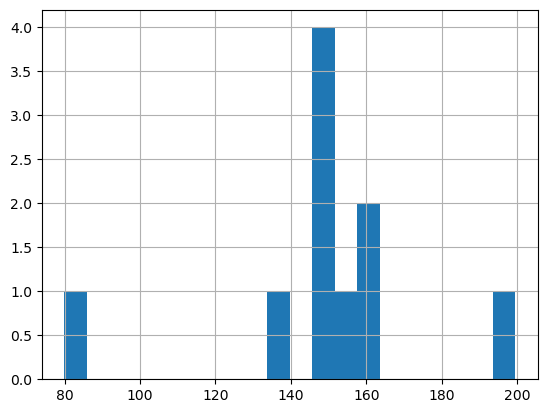

In [11]:
prezzo_tipo = df_NG_salvato.groupby("Tipo")["Prezzo"].agg(["mean", "min", "max", "count"]).round(2)
prezzo_tipo["mean"].hist(bins = 20)

In [14]:
from Library import *
df_NG = pd.read_csv("Azienda NG.csv")
df_NG

,Scarpe,Prezzo,Materiale,Tipo,Sottotipo
0,Men's Leather Loafers,139.5,Leather,Loafers,Leather Loafers
1,Men's Leather Loafers,139.5,Leather,Loafers,Leather Loafers
2,Men's Leather Loafers,139.5,Leather,Loafers,Leather Loafers
3,Men's Patent Oxford Shoes,149.5,Patent,Oxford Shoes,Patent Oxford Shoes
4,Men's Leather Derbys,149.5,Leather,Derby Shoes,Leather Derby Shoes
...,...,...,...,...,...
155,Men's Suede Sneakers,139.5,Suede,Sneakers,Low Sneakers
156,Men's Suede Sneakers,139.5,Suede,Sneakers,Low Sneakers
157,Men's Leather And Suede Sneakers,149.5,Leather,Sneakers,Low Sneakers
158,Men's Leather And Suede Sneakers,149.5,Leather,Sneakers,Low Sneakers


## 5. Profondità di Gamma: Varianti Colore vs Modelli
Un aspetto cruciale per comprendere la strategia commerciale dell'Azienda NG è distinguere tra "referenze a catalogo" (che includono i diversi colori) e "modelli unici". 

Deduplicando il dataset per *Nome, Prezzo e Tipo*, riusciamo a isolare i veri e propri modelli stampo, calcolando quante varianti colore vengono offerte in media per ogni silhouette.

In [15]:
print(f"Righe totali (con varianti colore): {len(df_NG)}")

df_NG_modelli = df_NG.drop_duplicates(subset=["Scarpe", "Prezzo", "Tipo"])
print(f"Modelli unici (senza varianti colore): {len(df_NG_modelli)}")
print(f"Varianti colore medie per modello: {len(df_NG) / len(df_NG_modelli):.1f}")

Righe totali (con varianti colore): 160
Modelli unici (senza varianti colore): 48
Varianti colore medie per modello: 3.3


## 6. Mappatura Tassonomica Standard
Avendo dedotto le tipologie primarie, traduciamo l'offerta dell'Azienda NG nella tassonomia standard comparabile (Macro-categoria e Micro-categoria) utilizzando un dizionario di mappatura dedicato. Questo passaggio unifica diciture come "Derby Shoes" o "Oxford Shoes" all'interno del segmento "Scarpe eleganti".

In [16]:
MACRO_MICRO_NG_TIPO = {
    "Sneakers":("Sneakers","Sneakers basse"),
    "Loafers":("Mocassini","Mocassini"),
    "Derby Shoes":("Scarpe eleganti","Stringate / Derby"),
    "Tie-Up Shoes":("Scarpe eleganti","Stringate / Derby"),
    "Oxford Shoes":("Scarpe eleganti","Stringate / Derby"),
    "Buckle Shoes":("Scarpe eleganti","Stringate / Derby"),
    "Slippers":("Ciabatte & Pantofole", "Ciabatte"),
    "Chelsea Boots":("Stivali & Stivaletti", "Stivaletti"),
    "Desert Boots":("Stivali & Stivaletti", "Stivaletti"),
    "Combat Boots":("Stivali & Stivaletti", "Stivali"),}

MAP_MICRO_SOTTOTIPO = {
    "Low Sneakers":"Sneakers basse",
    "High Top Sneakers":"Sneakers alte",
    "Leather Loafers":"Mocassini",
    "Suede Loafers":"Mocassini",
    "Leather Derby Shoes":"Stringate / Derby",
    "Suede Derby Shoes":"Stringate / Derby",
    "Patent Derby Shoes":"Stringate / Derby",
    "Leather Tie-Up Shoes":"Stringate / Derby",
    "Suede Tie-Up Shoes":"Stringate / Derby",
    "Patent Tie-Up Shoes":"Stringate / Derby",
    "Patent Oxford Shoes":"Stringate / Derby",
    "Leather Buckle Shoes":"Stringate / Derby",
    "Leather Slippers":"Ciabatte",
    "Suede Slippers":"Ciabatte",
    "Leather Chelsea Boots": "Stivaletti",
    "Suede Chelsea Boots":"Stivaletti",
    "Suede Desert Boots":"Stivaletti",
    "Leather Combat Boots":"Stivali",}

df_NG["Macro_categoria"] = df_NG["Tipo"].apply(
    lambda x: MACRO_MICRO_NG_TIPO.get(x, ("Altro", "Altro"))[0]
)
df_NG["Micro_categoria"] = df_NG["Sottotipo"].apply(
    lambda x: MAP_MICRO_SOTTOTIPO.get(x, "Altro")
)

df_NG.loc[df_NG["Sottotipo"] == "High Top Sneakers", "Macro_categoria"] = "Sneakers"

df_NG_modelli = df_NG.drop_duplicates(subset=["Scarpe", "Prezzo", "Tipo"])

non_mappati = df_NG[df_NG["Macro_categoria"] == "Altro"]["Tipo"].unique()
print(f"Categorie non mappate: {non_mappati if len(non_mappati) else 'Nessuna'}")
print(df_NG[["Macro_categoria", "Micro_categoria"]].value_counts())

Categorie non mappate: Nessuna
Macro_categoria       Micro_categoria  
Sneakers              Sneakers basse       71
Scarpe eleganti       Stringate / Derby    33
Mocassini             Mocassini            30
Stivali & Stivaletti  Stivaletti           13
Ciabatte & Pantofole  Ciabatte              9
Sneakers              Sneakers alte         2
Stivali & Stivaletti  Stivali               2
Name: count, dtype: int64


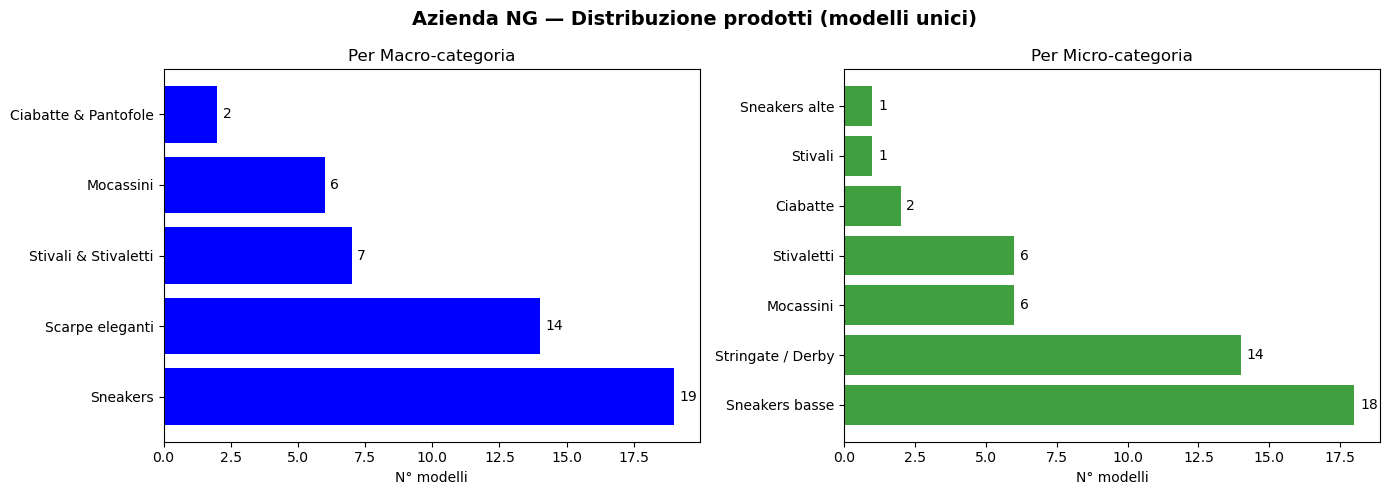

In [19]:
fig, n1 = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Azienda NG — Distribuzione prodotti (modelli unici)", 
             fontsize=14, fontweight="bold")

macro_counts = df_NG_modelli["Macro_categoria"].value_counts()
n1[0].barh(macro_counts.index, macro_counts.values, color="blue")
n1[0].set_title("Per Macro-categoria")
n1[0].set_xlabel("N° modelli")
for i, v in enumerate(macro_counts.values):
    n1[0].text(v + 0.2, i, str(v), va="center")

micro_counts = df_NG_modelli["Micro_categoria"].value_counts()
n1[1].barh(micro_counts.index, micro_counts.values, color="green", alpha=0.75)
n1[1].set_title("Per Micro-categoria")
n1[1].set_xlabel("N° modelli")
for i, v in enumerate(micro_counts.values):
    n1[1].text(v + 0.2, i, str(v), va="center")

plt.tight_layout()
plt.show()

=== Distribuzione per Materiale ===
Materiale
Leather    30
Suede      15
Patent      3
Name: count, dtype: int64



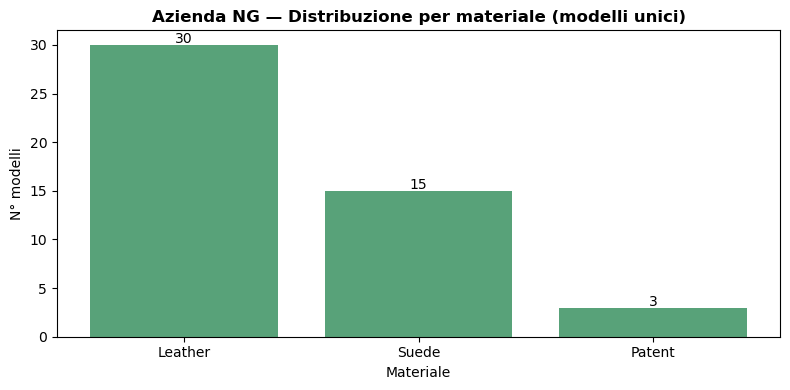


=== Materiale per Macro-categoria ===
Materiale             Leather  Patent  Suede
Macro_categoria                             
Ciabatte & Pantofole        1       0      1
Mocassini                   4       0      2
Scarpe eleganti             7       3      4
Sneakers                   14       0      5
Stivali & Stivaletti        4       0      3


In [20]:
print("=== Distribuzione per Materiale ===")
print(df_NG_modelli["Materiale"].value_counts())
print()

fig, n2 = plt.subplots(figsize=(8, 4))
mat_counts = df_NG_modelli["Materiale"].value_counts()
n2.bar(mat_counts.index, mat_counts.values, color="seagreen", alpha=0.8)
n2.set_title("Azienda NG — Distribuzione per materiale (modelli unici)", fontweight="bold")
n2.set_xlabel("Materiale")
n2.set_ylabel("N° modelli")
for i, v in enumerate(mat_counts.values):
    n2.text(i, v + 0.2, str(v), ha="center")
plt.tight_layout()
plt.show()

# Materiale per macro-categoria
print("\n=== Materiale per Macro-categoria ===")
print(pd.crosstab(df_NG_modelli["Macro_categoria"], df_NG_modelli["Materiale"]))

In [21]:
print("=== Statistiche prezzi (modelli unici) ===")
print(df_NG_modelli["Prezzo"].describe().round(2))

print("\n=== Prezzi per Macro-categoria ===")
print(df_NG_modelli.groupby("Macro_categoria")["Prezzo"].agg(
    Media="mean", Minimo="min", Massimo="max", N="count"
).round(2))

print("\n=== Prezzi per Micro-categoria ===")
print(df_NG_modelli.groupby("Micro_categoria")["Prezzo"].agg(
    Media="mean", Minimo="min", Massimo="max", N="count"
).round(2))

=== Statistiche prezzi (modelli unici) ===
count     48.00
mean     154.05
std       34.53
min       75.00
25%      143.62
50%      149.50
75%      159.50
max      349.00
Name: Prezzo, dtype: float64

=== Prezzi per Macro-categoria ===
                       Media  Minimo  Massimo   N
Macro_categoria                                  
Ciabatte & Pantofole   82.45    75.0     89.9   2
Mocassini             147.83   139.5    159.5   6
Scarpe eleganti       150.29   139.5    159.5  14
Sneakers              161.92   129.5    349.0  19
Stivali & Stivaletti  166.00   139.5    199.5   7

=== Prezzi per Micro-categoria ===
                    Media  Minimo  Massimo   N
Micro_categoria                               
Ciabatte            82.45    75.0     89.9   2
Mocassini          147.83   139.5    159.5   6
Sneakers alte      189.50   189.5    189.5   1
Sneakers basse     160.39   129.5    349.0  18
Stivaletti         160.42   139.5    179.5   6
Stivali            199.50   199.5    199.5   1
St

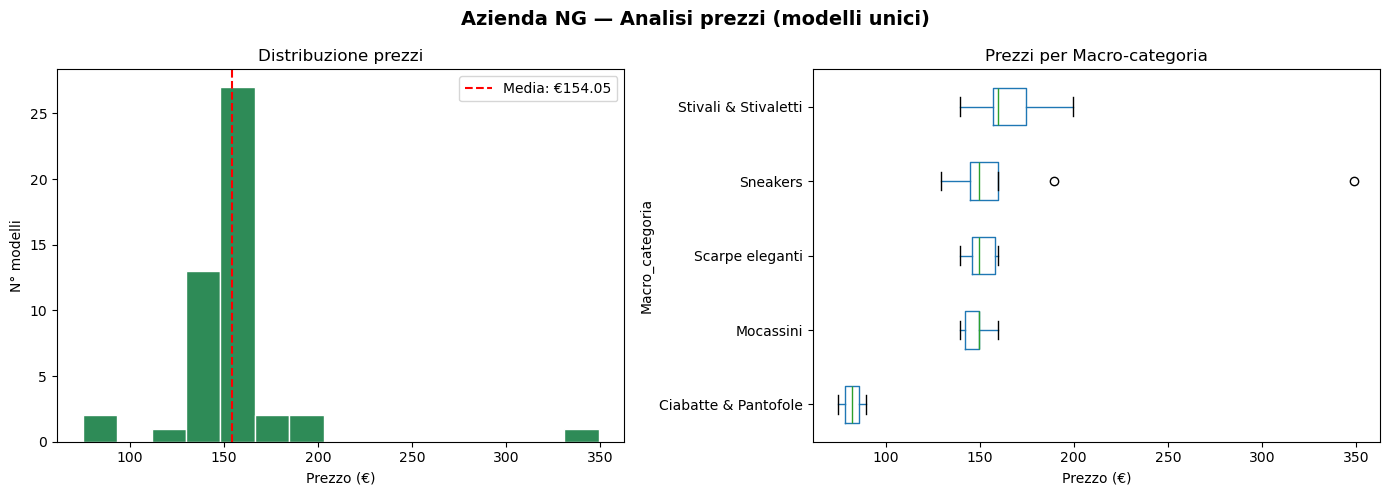

In [23]:
fig, n3 = plt.subplots(1, 2, figsize=(14, 5))

n3[0].hist(df_NG_modelli["Prezzo"], bins=15, color="seagreen", edgecolor="white")
n3[0].axvline(df_NG_modelli["Prezzo"].mean(), color="red", linestyle="--",
                label=f'Media: €{df_NG_modelli["Prezzo"].mean():.2f}')
n3[0].set_title("Distribuzione prezzi")
n3[0].set_xlabel("Prezzo (€)")
n3[0].set_ylabel("N° modelli")
n3[0].legend()

df_NG_modelli.boxplot(column="Prezzo", by="Macro_categoria", ax=n3[1],
                      grid=False, vert=False)
n3[1].set_title("Prezzi per Macro-categoria")
n3[1].set_xlabel("Prezzo (€)")
plt.suptitle("")
fig.suptitle("Azienda NG — Analisi prezzi (modelli unici)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [24]:
df_NG["Brand"] = "NG"
df_NG_modelli["Brand"] = "NG"

# Con varianti colore (utile per analisi bonus colori)
df_NG.to_csv("Azienda_NG_clean.csv", index=False)

# Solo modelli unici (utile per confronti equi con G e C)
df_NG_modelli.to_csv("Azienda_NG_modelli.csv", index=False)

print("Azienda_NG_clean.csv salvato (con varianti colore)")
print(f"Righe: {len(df_NG)}")
print("Azienda_NG_modelli.csv salvato (modelli unici)")
print(f"Righe: {len(df_NG_modelli)}")

Azienda_NG_clean.csv salvato (con varianti colore)
  Righe: 160
Azienda_NG_modelli.csv salvato (modelli unici)
  Righe: 48


C:\Users\ssi106\AppData\Local\Temp\ipykernel_3376\3575140914.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_NG_modelli["Brand"] = "NG"


## 7. Conclusioni e Key Takeaways (Azienda NG)

L'analisi del processo di pricing e dell'assortimento dell'Azienda NG restituisce l'immagine di un brand estremamente mirato, con una struttura d'offerta ben definita:

* **Efficienza di Gamma e Varietà Colore:** Il catalogo è apparentemente ridotto (solo 48 modelli unici), ma viene abilmente espanso offrendo varianti colore per modello. È un dato eccellente che garantisce un effetto di vastità dell'offerta ottimizzando i costi di produzione (stesso stampo, pellami diversi).
* **Strategia di Pricing a "Spike":** Il pricing è chirurgico. Piuttosto che avere una distribuzione piatta, vi è un picco nettissimo (spike) nella fascia **€149 – €159**, con una dispersione minima. L'azienda conosce perfettamente il *willingness-to-pay* del suo cliente target e vi si posiziona in modo deliberato.
* **Premiumization mirata (Outlier):** Nelle Sneakers emergono due chiari outlier rispetto alla media del brand, posizionati a circa €190 (modelli High Top) e un picco isolato a **€349**. Questa è quasi certamente un'edizione speciale o una *premium capsule*, un dettaglio strategico molto interessante da portare all'attenzione del management.
* **Pellami Tradizionali:** Il materiale "Leather" domina la collezione (30 modelli su 48), affiancato dallo "Suede" (15 modelli). L'uso della pelle verniciata ("Patent") è limitato ed esclusivo per la categoria formale.
* **Vuoto d'offerta Estivo:** Proprio come osservato nel caso dell'Azienda G, la categoria *Sandali* è completamente assente. Si conferma un potenziale vuoto di mercato condiviso tra i competitor analizzati.